# SDA: Fitting diffuse interstellar bands (DIBs)

We will use data from the ESO Diffuse Interstellar Bands Large Exploration Survey (EDIBLES). The data were obtained with observations with the Ultraviolet and Visual Echelle Spectrograph (UVES) on the Very Large Telescope (VLT) at Cerro Paranal in Chile. The data file includes a small part of the complete spectrum, covering a diffuse interstellar band (DIB).

The data are available on [Github](https://github.com/jancami/edibles) and the related publication can be found through [ADS](https://ui.adsabs.harvard.edu/abs/2017A%26A...606A..76C).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import ascii
from scipy import stats

In [2]:
plt.rcParams["figure.figsize"] = (6, 3)
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

## Read the data

In [3]:
dibs_data = ascii.read("dibs_data.csv", format="csv")
print(dibs_data)

Wavelength   Flux 
---------- -------
 5768.8198 272.857
 5768.8398 273.178
 5768.8599 273.242
 5768.8799 272.953
 5768.8999 273.004
 5768.9199 273.436
 5768.9399 273.502
   5768.96 273.476
   5768.98 273.265
    5769.0 273.061
       ...     ...
 5770.0601 273.563
 5770.0801 273.304
 5770.1001 273.096
 5770.1201 273.018
 5770.1401 272.939
 5770.1602 272.822
 5770.1802 273.379
 5770.2002 272.946
 5770.2202 273.212
 5770.2402 273.196
Length = 72 rows


We add an approximate (constant) uncertainty, by adopting the approximate S/N of 700 from the article

In [4]:
dibs_data['e_Flux'] = dibs_data['Flux']/700

## Plot the spectrum

Let's first plot the data to have a look at the spectral DIB feature.

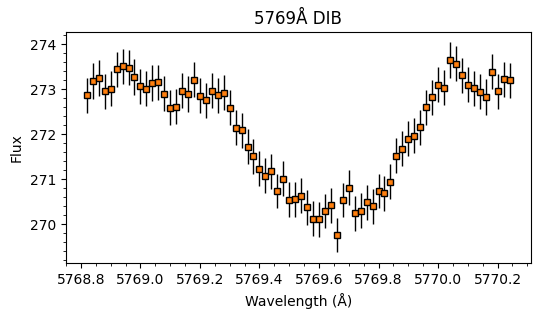

In [5]:
plt.figure(figsize=(6, 3))
plt.errorbar(dibs_data['Wavelength'], dibs_data['Flux'], yerr=dibs_data['e_Flux'],
             marker='s', ms=5, ls='none', color='tab:orange', ecolor='black', mec='black', mew=1, elinewidth=1)
plt.title('5769Å DIB')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.minorticks_on()
plt.show()

## Define functions for the line profiles

Next, we define functions for a [Gaussian](https://en.wikipedia.org/wiki/Normal_distribution) and [Lorentzian](https://en.wikipedia.org/wiki/Spectral_line_shape#Lorentzian) line profile.

In [6]:
def gaussian_profile(wavelength, continuum, amplitude, w0, sigma):
    """
    Gaussian absorption line profile.

    Parameters
    ----------
    wavelength : array
        Wavelength values (same units as w0).
    continuum : float
        Constant continuum level.
    amplitude : float
        Depth of the absorption line.
    w0 : float
        Central wavelength of the line.
    sigma : float
        Standard deviation of the line profile.

    Returns
    -------
    flux : array
        Model flux at each wavelength.
    """

    # Normalized Gaussian profile
    profile = np.exp(-0.5 * ((wavelength - w0) / sigma)**2)

    # Absorption line: continuum minus Gaussian profile
    return continuum - amplitude * profile

In [8]:
def lorentzian_profile(wavelength, continuum, amplitude, w0, fwhm):
    """
    Lorentzian absorption line profile.

    Parameters
    ----------
    wavelength : array
        Wavelength values (same units as w0).
    continuum : float
        Constant continuum level.
    amplitude : float
        Depth of the absorption line.
    w0 : float
        Central wavelength of the line.
    fwhm : float
        Full width at half maximum (FWHM) of the line profile.

    Returns
    -------
    flux : array
        Model flux at each wavelength.
    """

    # Normalized Lorentzian profile
    profile = 1 / (1 + ((wavelength - w0) / (fwhm / 2))**2)

    # Absorption line: continuum minus Lorentzian profile
    return continuum - amplitude * profile

## Exercises

**Question 1**: Use the least-squares method to find the best-fit Gaussian and Lorentzian model parameters.

In [9]:
# least squares fitting of Gaussian profile
from scipy.optimize import least_squares
chi2_gaussian = least_squares(lambda p: (gaussian_profile(dibs_data['Wavelength'], *p) - dibs_data['Flux']) / dibs_data['e_Flux'],
                              x0=[1.0, 0.5, 5769.0, 1.0], bounds=([0, 0, 5768, 0], [np.inf, np.inf, 5770, np.inf]))
print("Gaussian fit parameters:", chi2_gaussian.x)

# least squares fitting of Lorentzian profile
chi2_lorentzian = least_squares(lambda p: (lorentzian_profile(dibs_data['Wavelength'], *p) - dibs_data['Flux']) / dibs_data['e_Flux'],
                                 x0=[1.0, 0.5, 5769.0, 1.0], bounds=([0, 0, 5768, 0], [np.inf, np.inf, 5770, np.inf]))
print("Lorentzian fit parameters:", chi2_lorentzian.x)

Gaussian fit parameters: [2.73224256e+02 3.17589266e+00 5.76962962e+03 2.02194108e-01]
Lorentzian fit parameters: [2.73849161e+02 3.84375438e+00 5.76962841e+03 5.41087826e-01]


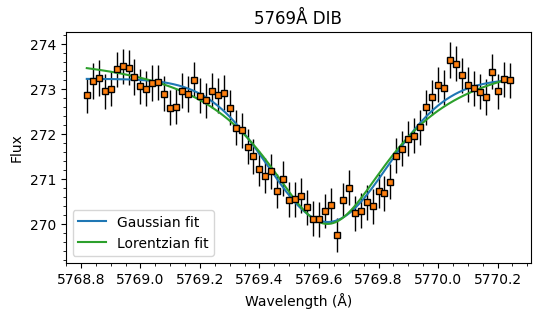

In [11]:
plt.figure(figsize=(6, 3))
plt.errorbar(dibs_data['Wavelength'], dibs_data['Flux'], yerr=dibs_data['e_Flux'],
             marker='s', ms=5, ls='none', color='tab:orange', ecolor='black', mec='black', mew=1, elinewidth=1)
plt.title('5769Å DIB')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.minorticks_on()

flux_x = np.linspace(np.min(dibs_data['Wavelength']), np.max(dibs_data['Wavelength']), 1000)
plt.plot(flux_x, gaussian_profile(flux_x, *chi2_gaussian.x), label='Gaussian fit', color='tab:blue')
plt.plot(flux_x, lorentzian_profile(flux_x, *chi2_lorentzian.x), label='Lorentzian fit', color='tab:green')
plt.legend()
plt.show()

**Question 2**: Compute the reduced $\chi^2$ of the best-fit model. Can you conclude anything about the reported uncertainties of the data?

In [12]:
# calc chi^2 for Gaussian fit
chi2_gaussian_value = np.sum(((gaussian_profile(dibs_data['Wavelength'], *chi2_gaussian.x) - dibs_data['Flux']) / dibs_data['e_Flux'])**2)
print("Chi^2 for Gaussian fit:", chi2_gaussian_value)
# calc chi^2 for Lorentzian fit
chi2_lorentzian_value = np.sum(((lorentzian_profile(dibs_data['Wavelength'], *chi2_lorentzian.x) - dibs_data['Flux']) / dibs_data['e_Flux'])**2)
print("Chi^2 for Lorentzian fit:", chi2_lorentzian_value)
DoF = len(dibs_data['Wavelength']) - 4  # number of data points minus number of fitted parameters
print("Degrees of freedom:", DoF)
reduced_chi2_gaussian = chi2_gaussian_value / DoF
reduced_chi2_lorentzian = chi2_lorentzian_value / DoF
print("Reduced Chi^2 for Gaussian fit:", reduced_chi2_gaussian)
print("Reduced Chi^2 for Lorentzian fit:", reduced_chi2_lorentzian)


Chi^2 for Gaussian fit: 36.452918627084784
Chi^2 for Lorentzian fit: 50.07782334414713
Degrees of freedom: 68
Reduced Chi^2 for Gaussian fit: 0.5360723327512469
Reduced Chi^2 for Lorentzian fit: 0.736438578590399
